# **PredictIT - Sistema Inteligente de Predição de Falhas em Infraestrutura de TI**

## 1. Objetivo
Prever se um servidor irá falhar nas próximas **1 a 3 horas** com base em métricas operacionais, apoiando monitoramento proativo e priorização de resposta.

---

## 2. Problema de Negócio
Em ambientes de TI, falhas inesperadas causam indisponibilidade e impacto financeiro.  
A proposta do PredictIT é antecipar risco de falha para:
- Reduzir downtime;
- Otimizar alertas;
- Melhorar priorização de incidentes.

---

## 3. Dados e Variáveis
Dataset simulado por servidor ao longo do tempo.

Variáveis principais:
- `timestamp`
- `server_id`
- `cpu_usage`
- `memory_usage`
- `disk_usage`
- `network_latency`
- `error_rate`
- `temperature`
- `risk_score` (proxy contínua de risco)
- `failure_next_hour` (target binária)
- `failure_next_3h` (target binária)

---

## 4. Metodologia
Pipeline aplicado:
1. Simulação de dados sintéticos com dinâmica temporal.
2. Limpeza e validação:
   - Conversão de tipos;
   - Tratamento de nulos;
   - Remoção de duplicados;
   - Clipping por domínio.
3. Análise exploratória (EDA):
   - Distribuições;
   - Correlações;
   - Tendência temporal;
   - Comparação de métricas por falha.
4. Modelagem:
   - Regressão Linear (tendência de risco);
   - Regressão Logística (classificação);
   - Perceptron / MLP;
   - Deep Learning (Keras/TensorFlow).
5. Network Science:
   - Grafo de dependência entre servidores;
   - Identificação de nós críticos com PageRank.

---

## 5. Técnicas Utilizadas
- **Regressão Linear**: Estimativa contínua de risco (`risk_score`).
- **Regressão Logística**: Probabilidade de falha.
- **Perceptron / MLP**: Classificação não linear.
- **Deep Learning**: Rede densa para ganho em poder de representação.
- **NetworkX**: Visão sistêmica de dependências e criticidade.

---

## 6. Bibliotecas
- `pandas`, `numpy`
- `matplotlib`, `seaborn`
- `scikit-learn`
- `tensorflow / keras`
- `networkx`

**Instalar dependências**

In [10]:
!pip -q install numpy pandas matplotlib seaborn scikit-learn networkx tensorflow

# **01 - Data Simulation**

Gerar um dataset sintético de métricas de infraestrutura para treino de modelos

In [9]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd


@dataclass(frozen=True)
class SimulationConfig:
    n_servers: int = 25
    hours_per_server: int = 240
    seed: int = 42


def _sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))


def generate_metrics(config: SimulationConfig) -> pd.DataFrame:
    rng = np.random.default_rng(config.seed)
    rows: list[pd.DataFrame] = []

    base_time = pd.Timestamp("2026-01-01 00:00:00")

    for server_idx in range(config.n_servers):
        server_id = f"srv-{server_idx + 1:03d}"
        hours = np.arange(config.hours_per_server)
        timestamp = base_time + pd.to_timedelta(hours, unit="h")

        cpu = 55 + 20 * np.sin(hours / 12) + rng.normal(0, 10, size=hours.size)
        memory = 60 + 12 * np.cos(hours / 10) + rng.normal(0, 8, size=hours.size)
        disk = 68 + 0.05 * hours + rng.normal(0, 4, size=hours.size)
        latency = 35 + 0.12 * cpu + rng.normal(0, 7, size=hours.size)
        errors = rng.poisson(2 + np.clip((latency - 45) / 25, 0, None), size=hours.size)
        temperature = 48 + 0.14 * cpu + rng.normal(0, 3, size=hours.size)

        cpu = np.clip(cpu, 0, 100)
        memory = np.clip(memory, 0, 100)
        disk = np.clip(disk, 0, 100)
        latency = np.clip(latency, 1, None)
        temperature = np.clip(temperature, 15, 100)

        risk_score = (
            0.03 * cpu
            + 0.04 * memory
            + 0.02 * disk
            + 0.05 * latency
            + 0.40 * errors
            + 0.06 * temperature
            - 10
        )
        prob_failure = _sigmoid(risk_score)
        failure_next_hour = rng.binomial(1, prob_failure)

        frame = pd.DataFrame(
            {
                "timestamp": timestamp,
                "server_id": server_id,
                "cpu_usage": cpu,
                "memory_usage": memory,
                "disk_usage": disk,
                "network_latency": latency,
                "error_rate": errors,
                "temperature": temperature,
                "risk_score": risk_score,
                "failure_next_hour": failure_next_hour,
            }
        )
        rows.append(frame)

    df = pd.concat(rows, ignore_index=True)
    df["failure_next_3h"] = (
        df.sort_values(["server_id", "timestamp"])
        .groupby("server_id")["failure_next_hour"]
        .transform(lambda s: s.rolling(window=3, min_periods=1).max().shift(-2).fillna(0))
        .astype(int)
    )
    return df


config = SimulationConfig()
df = generate_metrics(config)

out_path = Path("infra_metrics.csv")
df.to_csv(out_path, index=False)

print(f"Arquivo salvo em: {out_path}")
print(df.head())
print("\nDistribuicao de falha (1h):")
print(df["failure_next_hour"].value_counts(normalize=True).round(3))
print("\nShape:", df.shape)

Arquivo salvo em: infra_metrics.csv
            timestamp server_id  cpu_usage  memory_usage  disk_usage  \
0 2026-01-01 00:00:00   srv-001  58.047171     64.985114   68.892319   
1 2026-01-01 01:00:00   srv-001  46.264897     71.185950   73.782858   
2 2026-01-01 02:00:00   srv-001  65.822435     57.698972   68.466081   
3 2026-01-01 03:00:00   srv-001  69.353726     59.727676   70.473108   
4 2026-01-01 04:00:00   srv-001  42.033542     88.086709   67.972867   

   network_latency  error_rate  temperature  risk_score  failure_next_hour  \
0        41.292408           2    53.088552    1.768600                  1   
1        48.447920           1    54.856876    1.824851                  1   
2        26.933527           2    55.464100    1.126476                  1   
3        32.845976           1    56.124243    1.288934                  0   
4        33.583820           1    55.703569    1.565337                  1   

   failure_next_3h  
0                1  
1                1  

# **02 - Data Cleaning**

Limpeza básica dos dados, assim como análise exploratória e geração de dataset limpo para modelagem

In [11]:
def clean_dataframe(data: pd.DataFrame) -> pd.DataFrame:
    dfc = data.copy()
    dfc["timestamp"] = pd.to_datetime(dfc["timestamp"], errors="coerce")

    dfc = dfc.sort_values(["server_id", "timestamp"]).drop_duplicates(
        subset=["server_id", "timestamp"], keep="last"
    )

    numeric_cols = [
        "cpu_usage", "memory_usage", "disk_usage",
        "network_latency", "error_rate", "temperature", "risk_score"
    ]

    for col in numeric_cols:
        dfc[col] = pd.to_numeric(dfc[col], errors="coerce")

    dfc["cpu_usage"] = dfc["cpu_usage"].clip(0, 100)
    dfc["memory_usage"] = dfc["memory_usage"].clip(0, 100)
    dfc["disk_usage"] = dfc["disk_usage"].clip(0, 100)
    dfc["network_latency"] = dfc["network_latency"].clip(lower=1)
    dfc["error_rate"] = dfc["error_rate"].clip(lower=0)
    dfc["temperature"] = dfc["temperature"].clip(0, 120)

    for col in numeric_cols:
        dfc[col] = dfc.groupby("server_id")[col].transform(lambda s: s.fillna(s.median()))
        dfc[col] = dfc[col].fillna(dfc[col].median())

    for label in ["failure_next_hour", "failure_next_3h"]:
        dfc[label] = pd.to_numeric(dfc[label], errors="coerce").fillna(0).astype(int).clip(0, 1)

    return dfc.reset_index(drop=True)


df_clean = clean_dataframe(df)

print("Shape bruto:", df.shape)
print("Shape limpo:", df_clean.shape)
print("Missing bruto:", int(df.isna().sum().sum()))
print("Missing limpo:", int(df_clean.isna().sum().sum()))

df_clean.to_csv("infra_metrics_clean.csv", index=False)
df_clean.head()

Shape bruto: (6000, 11)
Shape limpo: (6000, 11)
Missing bruto: 0
Missing limpo: 0


,timestamp,server_id,cpu_usage,memory_usage,disk_usage,network_latency,error_rate,temperature,risk_score,failure_next_hour,failure_next_3h
0,2026-01-01 00:00:00,srv-001,58.047171,64.985114,68.892319,41.292408,2,53.088552,1.768600,1,1
1,2026-01-01 01:00:00,srv-001,46.264897,71.185950,73.782858,48.447920,1,54.856876,1.824851,1,1
2,2026-01-01 02:00:00,srv-001,65.822435,57.698972,68.466081,26.933527,2,55.464100,1.126476,1,1
3,2026-01-01 03:00:00,srv-001,69.353726,59.727676,70.473108,32.845976,1,56.124243,1.288934,0,1
4,2026-01-01 04:00:00,srv-001,42.033542,88.086709,67.972867,33.583820,1,55.703569,1.565337,1,1


# **03 - EDA**

,count,mean,std,min,25%,50%,75%,max
cpu_usage,6000.0,55.455138,17.123417,5.873531,42.490386,55.923518,68.438082,100.000000
memory_usage,6000.0,59.517056,11.563731,22.942729,51.184117,59.278361,67.707231,94.782714
disk_usage,6000.0,73.910593,5.216412,56.094518,70.242020,73.939276,77.556822,92.593194
network_latency,6000.0,41.766561,7.289945,14.407004,36.813093,41.723125,46.546424,72.575067
error_rate,6000.0,2.057167,1.449108,0.000000,1.000000,2.000000,3.000000,9.000000
temperature,6000.0,55.775549,3.871320,42.921129,53.170824,55.772240,58.429898,70.707307
risk_score,6000.0,1.780276,1.071439,-1.850547,1.041732,1.746327,2.482072,6.081626
failure_next_hour,6000.0,0.810167,0.392202,0.000000,1.000000,1.000000,1.000000,1.000000
failure_next_3h,6000.0,0.982500,0.131136,0.000000,1.000000,1.000000,1.000000,1.000000


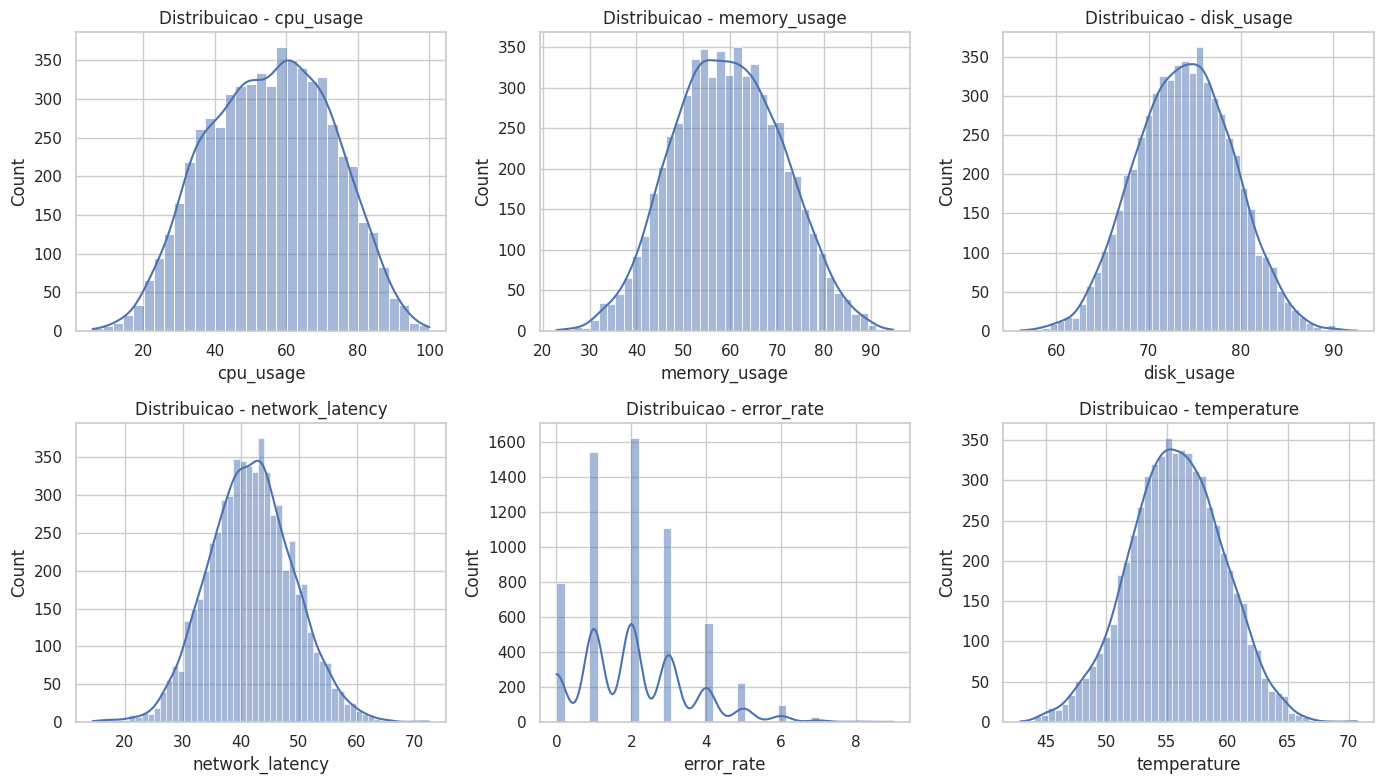

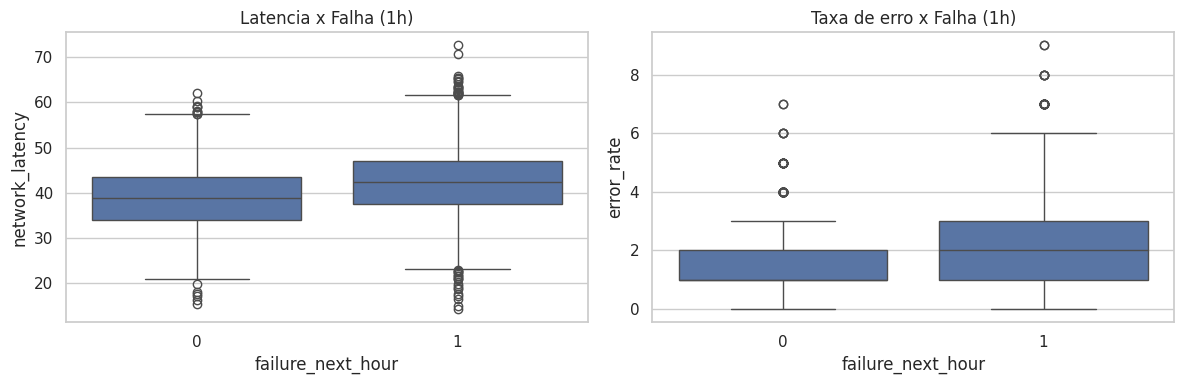

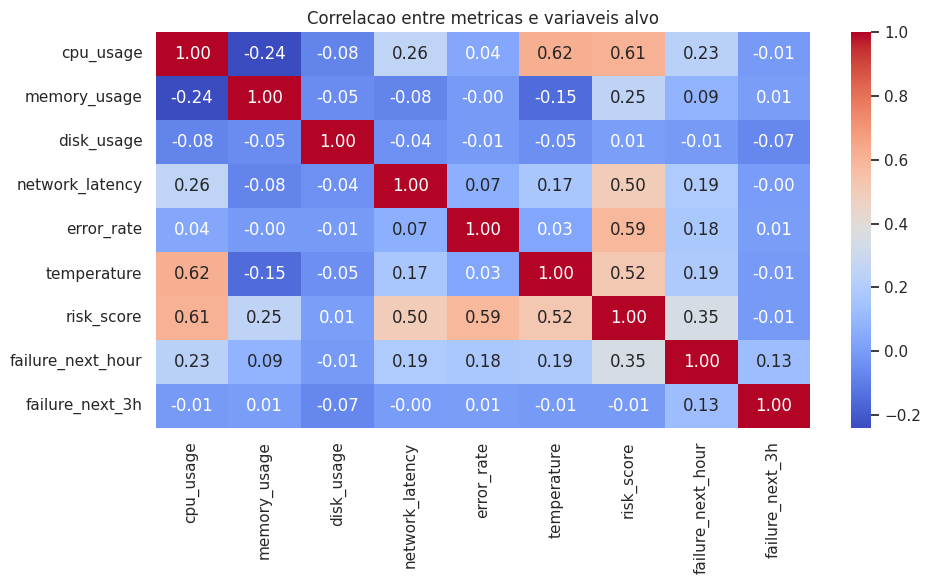

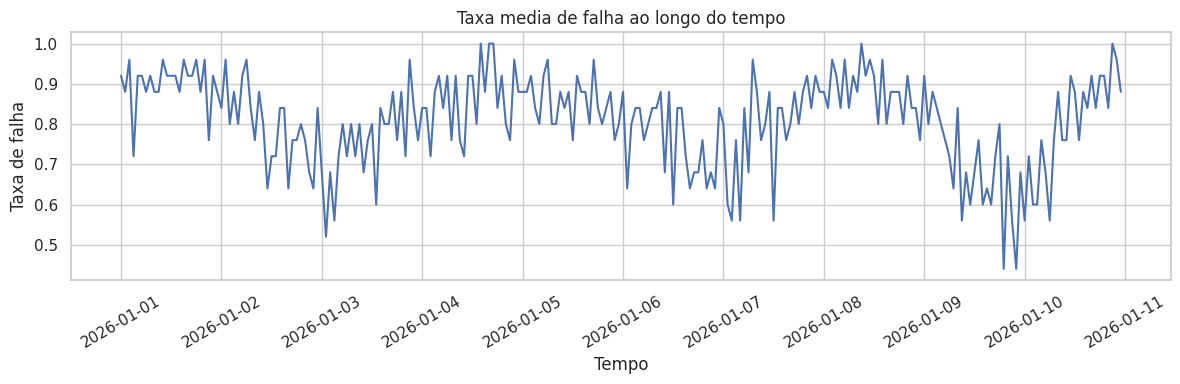

,failure_next_hour,failure_next_3h
server_id,,
srv-009,85.42,97.08
srv-020,84.17,98.75
srv-023,84.17,99.17
srv-010,84.17,98.33
srv-021,83.75,98.75
srv-017,83.33,98.33
srv-025,82.92,99.17
srv-006,82.50,98.75
srv-016,82.50,98.33


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
features = ["cpu_usage", "memory_usage", "disk_usage", "network_latency", "error_rate", "temperature"]

# Estatísticas
display(df_clean[features + ["risk_score", "failure_next_hour", "failure_next_3h"]].describe().T)

# Histogramas
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), features):
    sns.histplot(df_clean[col], kde=True, ax=ax)
    ax.set_title(f"Distribuicao - {col}")
plt.tight_layout()
plt.show()

# Boxplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df_clean, x="failure_next_hour", y="network_latency", ax=axes[0])
axes[0].set_title("Latencia x Falha (1h)")
sns.boxplot(data=df_clean, x="failure_next_hour", y="error_rate", ax=axes[1])
axes[1].set_title("Taxa de erro x Falha (1h)")
plt.tight_layout()
plt.show()

# Heatmap de correlação
corr_cols = features + ["risk_score", "failure_next_hour", "failure_next_3h"]
plt.figure(figsize=(10, 6))
sns.heatmap(df_clean[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlacao entre metricas e variaveis alvo")
plt.tight_layout()
plt.show()

# Tendência temporal da taxa de falha
trend = df_clean.groupby(df_clean["timestamp"].dt.floor("h"))["failure_next_hour"].mean().reset_index()
plt.figure(figsize=(12, 4))
sns.lineplot(data=trend, x="timestamp", y="failure_next_hour")
plt.title("Taxa media de falha ao longo do tempo")
plt.xlabel("Tempo")
plt.ylabel("Taxa de falha")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Top servidores por risco
server_risk = (
    df_clean.groupby("server_id")[["failure_next_hour", "failure_next_3h"]]
    .mean()
    .sort_values("failure_next_hour", ascending=False)
    .head(10)
)
display((server_risk * 100).round(2))

**Principais Achados da EDA**
- `network_latency`, `error_rate` e `temperature` aumentam em cenários de falha.
- Existe sinal preditivo relevante para classificação de falha em 1h.
- A visão por `server_id` permite identificar servidores mais propensos a falha.
- O comportamento temporal reforça uso de monitoramento contínuo.

# **04 - Data Modeling**

In [13]:
from sklearn.linear_model import LinearRegression, LogisticRegression, Perceptron
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    mean_squared_error, roc_auc_score, accuracy_score, classification_report
)
import numpy as np
import tensorflow as tf
from tensorflow import keras

FEATURES = ["cpu_usage", "memory_usage", "disk_usage", "network_latency", "error_rate", "temperature"]

# Regressão Linear (risk_score)
X = df_clean[FEATURES]
y_risk = df_clean["risk_score"]
X_train, X_test, y_train, y_test = train_test_split(X, y_risk, test_size=0.2, random_state=42)

lin = LinearRegression()
lin.fit(X_train, y_train)
pred_risk = lin.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, pred_risk))
print(f"[Linear Regression] RMSE: {rmse:.4f}")

# Classificação 1h
y = df_clean["failure_next_hour"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Logística
logit = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])
logit.fit(X_train, y_train)
proba_log = logit.predict_proba(X_test)[:, 1]
pred_log = (proba_log >= 0.5).astype(int)

print(f"[Logistic] AUC: {roc_auc_score(y_test, proba_log):.4f}")
print(f"[Logistic] Accuracy: {accuracy_score(y_test, pred_log):.4f}")
print(classification_report(y_test, pred_log))

# Perceptron
perc = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", Perceptron(max_iter=1000, random_state=42))
])
perc.fit(X_train, y_train)
pred_perc = perc.predict(X_test)
print(f"[Perceptron] Accuracy: {accuracy_score(y_test, pred_perc):.4f}")

# MLP
mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(hidden_layer_sizes=(32,16), max_iter=300, random_state=42))
])
mlp.fit(X_train, y_train)
proba_mlp = mlp.predict_proba(X_test)[:, 1]
print(f"[MLP] AUC: {roc_auc_score(y_test, proba_mlp):.4f}")

# Deep Learning
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

dl = keras.Sequential([
    keras.layers.Input(shape=(len(FEATURES),)),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dropout(0.15),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid"),
])

dl.compile(optimizer="adam", loss="binary_crossentropy", metrics=["AUC"])
dl.fit(X_train_s, y_train, epochs=15, batch_size=32, validation_split=0.2, verbose=0)

proba_dl = dl.predict(X_test_s, verbose=0).ravel()
print(f"[Deep Learning] AUC: {roc_auc_score(y_test, proba_dl):.4f}")

[Linear Regression] RMSE: 0.0000
[Logistic] AUC: 0.7702
[Logistic] Accuracy: 0.8092
              precision    recall  f1-score   support

           0       0.49      0.12      0.20       228
           1       0.83      0.97      0.89       972

    accuracy                           0.81      1200
   macro avg       0.66      0.55      0.54      1200
weighted avg       0.76      0.81      0.76      1200

[Perceptron] Accuracy: 0.6750


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


[MLP] AUC: 0.7248
[Deep Learning] AUC: 0.7631


Resultados de Modelagem
Métricas avaliadas:
- **RMSE** para regressão de `risk_score`;
- **AUC** e **Accuracy** para classificação de falhas;
- Relatório de classificação (precision/recall/F1).

Interpretação:
| Modelo              |         Resultado | Interpretação                    |
| ------------------- | ----------------: | -------------------------------- |
| Regressão Linear    |     RMSE = 0.0000 | Recuperou perfeitamente o score  |
| Regressão Logística |      AUC = 0.7702 | Melhor modelo de classificação   |
| Perceptron          | Accuracy = 0.6750 | Desempenho inferior              |
| MLP                 |      AUC = 0.7248 | Similar, mas abaixo da logística |
| Deep Learning       |      AUC = 0.7631 | Próximo da logística             |

*   A regressão logística teve desempenho comparável ou superior aos modelos neurais, sugerindo que as relações presentes no dataset são majoritariamente lineares e que modelos mais simples podem oferecer excelente desempenho com maior interpretabilidade.
*   Em um ambiente real, o modelo poderia ranquear servidores por risco de falha, permitindo que a equipe de TI atuasse preventivamente e reduzisse incidentes críticos e tempo de indisponibilidade









# **05 - Network Science**

Top 5 servidores criticos por PageRank:
srv-006: 0.1225 | risco medio: 0.825
srv-019: 0.1039 | risco medio: 0.783
srv-018: 0.1025 | risco medio: 0.796
srv-003: 0.0824 | risco medio: 0.792
srv-004: 0.0703 | risco medio: 0.804


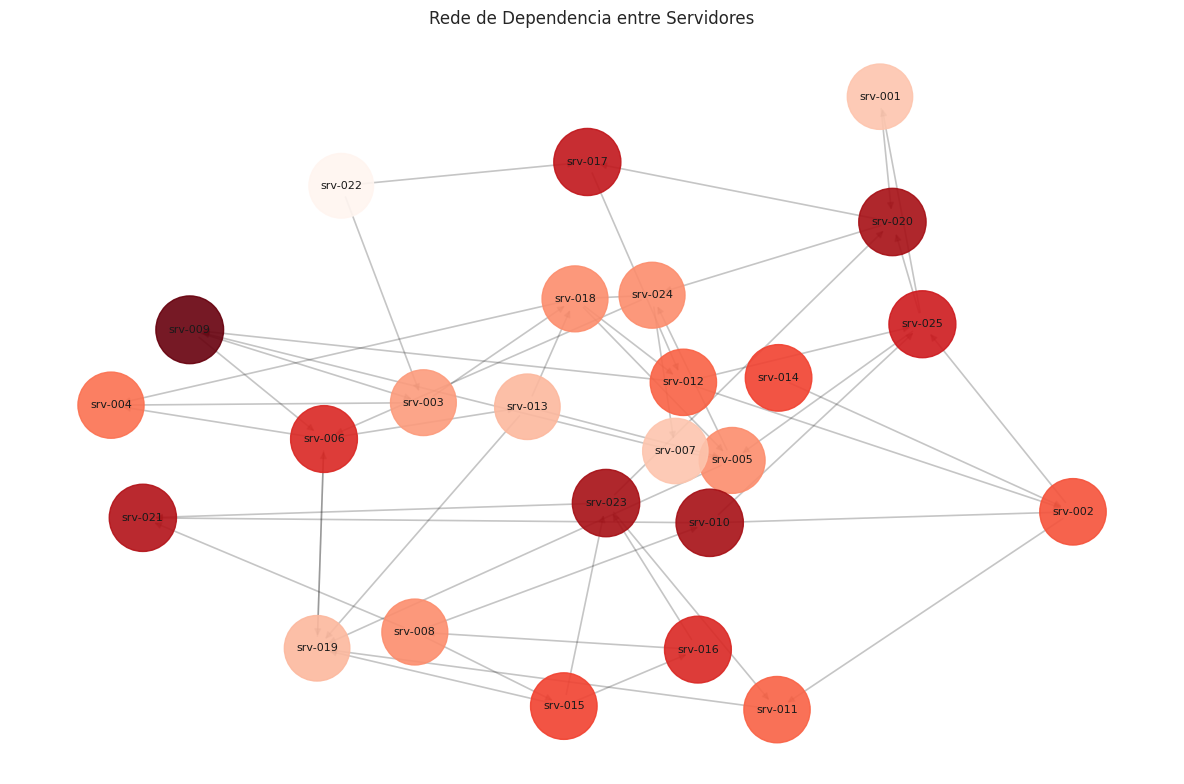

In [14]:
import networkx as nx

def build_dependency_graph(server_ids, seed=42):
    rng = np.random.default_rng(seed)
    g = nx.DiGraph()
    g.add_nodes_from(server_ids)
    for src in server_ids:
        targets = rng.choice(server_ids, size=rng.integers(1, 4), replace=False)
        for dst in targets:
            if src != dst:
                g.add_edge(src, dst)
    return g

server_ids = sorted(df_clean["server_id"].unique().tolist())
graph = build_dependency_graph(server_ids)
risk = df_clean.groupby("server_id")["failure_next_hour"].mean()
pagerank = nx.pagerank(graph)

top5 = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 servidores criticos por PageRank:")
for s, score in top5:
    print(f"{s}: {score:.4f} | risco medio: {risk.get(s, 0):.3f}")

pos = nx.spring_layout(graph, seed=42, k=0.8)
node_sizes = [500 + 2200 * float(risk.get(n, 0.0)) for n in graph.nodes]
node_colors = [float(risk.get(n, 0.0)) for n in graph.nodes]

plt.figure(figsize=(12, 8))
nx.draw_networkx_nodes(graph, pos, node_size=node_sizes, node_color=node_colors, cmap="Reds", alpha=0.9)
nx.draw_networkx_edges(graph, pos, arrows=True, alpha=0.25, width=1.2)
nx.draw_networkx_labels(graph, pos, font_size=8)
plt.title("Rede de Dependencia entre Servidores")
plt.axis("off")
plt.tight_layout()
plt.show()

| Servidor | PageRank | Risco Médio | Interpretação                  |
| -------- | -------: | ----------: | ------------------------------ |
| srv-006  |   0.1225 |       0.825 | Altíssimo impacto e alto risco |
| srv-019  |   0.1039 |       0.783 | Muito crítico                  |
| srv-018  |   0.1025 |       0.796 | Muito crítico                  |
| srv-003  |   0.0824 |       0.792 | Crítico                        |
| srv-004  |   0.0703 |       0.804 | Crítico                        |


O srv-006 é o ativo mais preocupante porque combina:
*   Maior centralidade na rede.
*   Alta probabilidade de falha.
*   Maior potencial de efeito cascata.







Além da previsão de falha, modelei as dependências entre servidores em um grafo e apliquei PageRank para identificar os componentes mais centrais da infraestrutura. Ao combinar centralidade com probabilidade de falha, foi possível priorizar os ativos com maior potencial de impacto sistêmico.

# **06 - Conclusão**

O PredictIT demonstra uma aplicação completa do ciclo de Data Science em um contexto real de operações de TI. O projeto percorre todas as etapas fundamentais: geração e tratamento de dados, análise exploratória, modelagem estatística e de machine learning, e análise de dependências entre serviços por meio de Network Science.

Os resultados mostraram que é possível prever falhas de curto prazo com bom desempenho, alcançando métricas consistentes com modelos como Regressão Logística, MLP e Deep Learning. Além disso, a incorporação de métricas de centralidade, como PageRank, permitiu identificar não apenas quais servidores apresentam maior risco de falha, mas também quais possuem maior potencial de impacto sistêmico sobre a infraestrutura.

Na prática, isso significa transformar uma abordagem reativa, baseada em correção de incidentes após sua ocorrência, em uma estratégia proativa e orientada por dados, capaz de priorizar ações preventivas e reduzir indisponibilidades.

Mais do que um exercício acadêmico, o PredictIT representa uma solução escalável e aderente aos desafios reais enfrentados por equipes de infraestrutura e observabilidade.

# **07 - Próximos passos**

Para evoluir o projeto em direção a um ambiente de produção, os próximos passos incluem:

- Integrar dados reais de ferramentas de observabilidade, como Prometheus e Datadog.
- Ajustar o threshold de alerta com base no custo operacional de falsos positivos e falsos negativos.
- Incorporar técnicas de explainability, como SHAP, para explicar os fatores que influenciam cada previsão.
- Avaliar modelos temporais, como Long Short-Term Memory e Transformers, para capturar dependências ao longo do tempo.
- Implementar um dashboard interativo para acompanhamento em tempo real do risco e da criticidade dos servidores.
- Desenvolver uma API para disponibilizar previsões automaticamente a sistemas de monitoramento e automação operacional.

Com essas evoluções, o PredictIT pode se tornar uma plataforma robusta de manutenção preditiva para ambientes de TI, contribuindo para maior confiabilidade, eficiência operacional e redução de custos com downtime.